<img src=logo.png width=300px>

# Snow simulation template

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import time

from soilice.src_snow import runModel
from soilice.balanceChecks import snowBalanceCheck

from soilice.snowParameters import pars
from soilice.constants import const

In [2]:
# start='18-Nov-2015'
# end='23-Nov-2015'
start='1-Oct-2015'
end='30-Sep-2019'
dd=pd.read_pickle('drivingdata.pkl')[start:end]

# FSM pre-processing:
# # Saturated specific humidity - verified Qsat is never less than Qa
# eps=0.622
# e0=611.213
# es = e0*np.exp(17.5043*dd['T'] / (241.3 + dd['T']))
# #     # Ice:
# # es = e0*np.exp(22.4422*dd['T'] / (272.186 + dd['T']))
# Qsat=eps*es/dd['BP']

# pl.plot(dd.index,Qsat)
# pl.plot(dd['SH'])

# ((Qsat-dd['SH'])<0).sum()


U=dd['U'].values
dd['U']=dd['U'].clip(lower=0.1)

# pl.plot(dd.index,U)
# pl.plot(dd['U'])


In [3]:
# Run the model
snow_df=runModel(dd,pars,const,msini=0,Tsini=0.,TSS=0,dz_soil=0.01)

/Users/ani378/Desktop/soilice_package/.venv/lib/python3.12/site-packages/scipy/integrate/_ode.py:438: UserWarning: vode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


ode, with jac runtime = 3.62 seconds


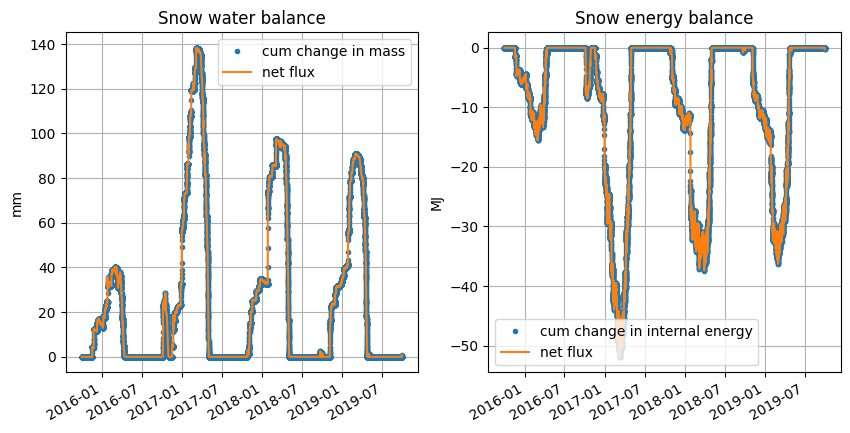

In [4]:
snowBalanceCheck(snow_df)

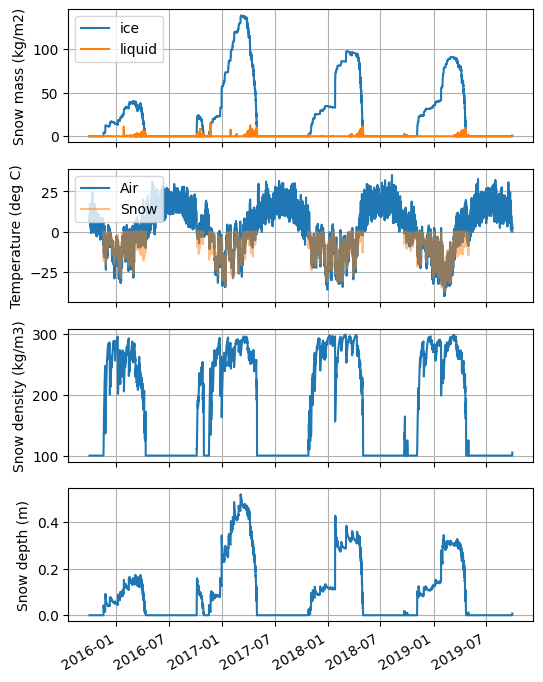

In [5]:
# Plots
d=dd.index
pl.figure(figsize=(6,9))
pl.subplot(4,1,1)
pl.plot(snow_df['mi'],label='ice')
pl.plot(snow_df['ml'],label='liquid')
pl.ylabel('Snow mass (kg/m2)'); pl.grid()
pl.legend()

pl.subplot(4,1,2)
pl.plot(snow_df['Ta'],label='Air')
pl.plot(snow_df['Ts'],label='Snow',alpha=0.5)
pl.legend()
pl.ylabel('Temperature (deg C)'); pl.grid()

pl.subplot(4,1,3)
pl.plot(snow_df['rhoS'])
pl.ylabel('Snow density (kg/m3)'); pl.grid()

pl.subplot(4,1,4)
# pl.plot(tD,msD/rhoSD)
pl.plot(snow_df['zs'])
pl.ylabel('Snow depth (m)'); pl.grid()

pl.gcf().autofmt_xdate()

# pl.savefig('temperature_balance_snow.png')